# Swiggy Datasets

In [68]:
# Libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load All Raw CSV Files

In [70]:
cd Raw_files

C:\Users\Lenovo\Swiggy_project\Raw_files


In [71]:

## ---------------------------------------------------------------

# loading files

orders = pd.read_csv('fact_orders.csv')
restaurants = pd.read_csv('dim_restaurant.csv')
locations = pd.read_csv('dim_location.csv')
dish = pd.read_csv('dim_dish.csv')
date = pd.read_csv('dim_date.csv')

## ----------------------------------------------------------------

print("All files are uploaded Successfully")

All files are uploaded Successfully


# orders Data Overview

In [73]:
# order table overview 

orders.head(10)

,order_id,date_id,location_id,restaurant_id,food_id,price,rating,rating_count
0,1,1,1,1,1,133.9,4.0,0
1,2,2,2,2,2,52.0,4.5,25
2,3,3,2,2,3,117.0,4.7,48
3,4,4,2,2,4,65.0,4.6,65
4,5,5,2,2,5,130.0,4.0,0
5,6,6,2,2,6,312.0,4.0,0
6,7,7,2,2,7,98.0,4.0,34
7,8,8,2,2,8,137.0,4.0,0
8,9,9,2,2,9,241.0,4.4,29
9,10,10,2,2,10,195.0,4.9,51


In [74]:
# order table details 
print(orders.shape)
print(80*'-')
print(orders.columns)
print(80*'-')
print(orders.describe())
print(80*'-')
print(orders.info())
print(80*'-')
print(orders.isnull().sum())
print(80*'-')
print(orders.duplicated().sum())

(197430, 8)
--------------------------------------------------------------------------------
Index(['order_id', 'date_id', 'location_id', 'restaurant_id', 'food_id',
       'price', 'rating', 'rating_count'],
      dtype='object')
--------------------------------------------------------------------------------
           order_id        date_id    location_id  restaurant_id  \
count  197430.00000  197430.000000  197430.000000  197430.000000   
mean    98715.50000     121.516092     471.434149     258.741686   
std     56993.27616      70.154857     302.904020     292.472935   
min         1.00000       1.000000       1.000000       1.000000   
25%     49358.25000      61.000000     206.000000      33.000000   
50%     98715.50000     122.000000     453.000000     100.000000   
75%    148072.75000     182.000000     747.000000     463.000000   
max    197430.00000     243.000000     995.000000     993.000000   

             food_id          price         rating   rating_count  
count  

### Orders Table — Data Quality Summary: 

The dataset is clean with 197,430 rows across 8 columns, zero nulls, and zero duplicates — ready for analysis without any imputation or deduplication needed. 
Average order value is ₹268.51, sitting comfortably in the mid-range, with a minimum of ₹0.95 (likely a test order or data entry error worth flagging) and a maximum of ₹8,000 (bulk/premium order).
All column datatypes are correct with no casting issues. 

One flag: the ₹0.95 minimum is suspicious — a real food order below ₹1 is practically impossible, so filtering out orders under ₹10 before final modelling is recommended.


# Restaurants Data Overview

In [77]:
restaurants.head(5)

,restaurant_id,restaurant_name
0,1,Anand Sweets & Savouries
1,2,Srinidhi Sagar Deluxe
2,3,Thalassery Restaurant
3,4,Appu Donne Biriyani Palace
4,5,Bismillah Taj Hotel


In [78]:
# restaurants table details
print(restaurants.columns)
print(80*'-')
print(restaurants.shape)
print(80*'-')
print(restaurants.info())
print(80*'-')
print(restaurants.isnull().sum())
print(80*'-')
print(restaurants.duplicated().sum())

Index(['restaurant_id', 'restaurant_name'], dtype='object')
--------------------------------------------------------------------------------
(993, 2)
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   restaurant_id    993 non-null    int64 
 1   restaurant_name  993 non-null    object
dtypes: int64(1), object(1)
memory usage: 15.6+ KB
None
--------------------------------------------------------------------------------
restaurant_id      0
restaurant_name    0
dtype: int64
--------------------------------------------------------------------------------
0


### Restaurants Table — Data Quality Summary: 

Small and clean dimension table with 993 unique restaurants across just 2 columns (restaurant_id, restaurant_name), zero nulls, and zero duplicates — every restaurant has a valid unique identifier. Being a dimension table, this is exactly the expected structure and needs no cleaning.

# Locations Data Overview :

In [81]:
locations.head(5)

,location_id,state,city,location
0,1,Karnataka,Bengaluru,Rajarajeshwari Nagar
1,2,Karnataka,Bengaluru,Kengeri
2,3,Karnataka,Bengaluru,Kanmanike Village
3,4,Karnataka,Bengaluru,Bidadi
4,5,Karnataka,Bengaluru,Kengeri Satellite Town


In [82]:
# locations table details
print(locations.columns)
print(80*'-')
print(locations.shape)
print(80*'-')
print(locations.info())
print(80*'-')
print(locations.isnull().sum())
print(80*'-')
print(locations.duplicated().sum())

Index(['location_id', 'state', 'city', 'location'], dtype='object')
--------------------------------------------------------------------------------
(995, 4)
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   location_id  995 non-null    int64 
 1   state        995 non-null    object
 2   city         995 non-null    object
 3   location     995 non-null    object
dtypes: int64(1), object(3)
memory usage: 31.2+ KB
None
--------------------------------------------------------------------------------
location_id    0
state          0
city           0
location       0
dtype: int64
--------------------------------------------------------------------------------
0


### Locations Table — Data Quality Summary: 

Clean dimension table with 995 rows across 4 columns (location_id, state, city, location) — zero nulls and zero duplicates confirm every location entry is complete and unique. 

# Dish Data Overview:

In [85]:
dish.head()

,dish_id,category,dish_name
0,1,Snack,Butter Murukku200gm
1,2,Recommended,Badam Milk
2,3,Recommended,Chow Chow Bath
3,4,Recommended,Kesari Bath
4,5,Recommended,Mix Raitha


In [86]:
# dish table details
print(dish.columns)
print(80*'-')
print(dish.shape)
print(80*'-')
print(dish.describe())
print(80*'-')
print(dish.info())
print(80*'-')
print(dish.isnull().sum())
print(80*'-')
print(dish.duplicated().sum())

Index(['dish_id', 'category', 'dish_name'], dtype='object')
--------------------------------------------------------------------------------
(82891, 3)
--------------------------------------------------------------------------------
            dish_id
count  82891.000000
mean   41446.000000
std    23928.714919
min        1.000000
25%    20723.500000
50%    41446.000000
75%    62168.500000
max    82891.000000
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82891 entries, 0 to 82890
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   dish_id    82891 non-null  int64 
 1   category   82891 non-null  object
 2   dish_name  82891 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.9+ MB
None
--------------------------------------------------------------------------------
dish_id      0
category     0
dish_name    0
dtype: int64
---------

#### Dish Table — Data Quality Summary: 

Large dimension table with 82,891 unique dishes across 3 columns (dish_id, category, dish_name) — zero nulls and zero duplicates confirm a fully clean catalogue.

# Date Table Overview :

In [89]:
date.head(5)

,date_id,order_date,year,month,month_name,day_of_week,is_weekend
0,1,2025-06-29,2025,6,Jun,Sunday,True
1,2,2025-04-03,2025,4,Apr,Thursday,False
2,3,2025-01-15,2025,1,Jan,Wednesday,False
3,4,2025-04-17,2025,4,Apr,Thursday,False
4,5,2025-03-13,2025,3,Mar,Thursday,False


In [90]:
# date table details
print(date.columns)
print(80*'-')
print(date.shape)
print(80*'-')
print(date.describe())
print(80*'-')
print(date.info())
print(80*'-')
print(date.isnull().sum())
print(80*'-')
print(date.duplicated().sum())

Index(['date_id', 'order_date', 'year', 'month', 'month_name', 'day_of_week',
       'is_weekend'],
      dtype='object')
--------------------------------------------------------------------------------
(243, 7)
--------------------------------------------------------------------------------
          date_id    year       month
count  243.000000   243.0  243.000000
mean   122.000000  2025.0    4.526749
std     70.292247     0.0    2.300356
min      1.000000  2025.0    1.000000
25%     61.500000  2025.0    3.000000
50%    122.000000  2025.0    5.000000
75%    182.500000  2025.0    7.000000
max    243.000000  2025.0    8.000000
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date_id      243 non-null    int64 
 1   order_date   243 non-null    object
 2   year       

### Date Table — Data Quality Summary:

Small and clean dimension table with 243 unique dates across 2 columns (date_id, order_date), zero nulls and zero duplicates — covering roughly 8 months of 2025 (Jan–Aug). 

One issue flagged: the order_date column is stored as object (string) instead of datetime dtype, which must be fixed before any time-series analysis, monthly grouping, or trend calculations

# Converting date column into date from object 


In [93]:
date["order_date"] = pd.to_datetime(date["order_date"])
print(date.info())
print(80*'-')
print(80*'-')
print("order_date column now have correct dtype as date")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date_id      243 non-null    int64         
 1   order_date   243 non-null    datetime64[ns]
 2   year         243 non-null    int64         
 3   month        243 non-null    int64         
 4   month_name   243 non-null    object        
 5   day_of_week  243 non-null    object        
 6   is_weekend   243 non-null    bool          
dtypes: bool(1), datetime64[ns](1), int64(3), object(2)
memory usage: 11.8+ KB
None
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
order_date column now have correct dtype as date


#### The order_date column was converted from object to datetime, then enriched with year, month, day of week, weekend flag columns. This turns the basic date table into a full time intelligence table, enabling monthly trends, weekday vs weekend comparison breakdowns across all 197,430 orders.

In [95]:
date["year"] = date["order_date"].dt.year
date["month"] = date["order_date"].dt.month
date["month_name"] = date["order_date"].dt.strftime("%b")
date["day_of_week"] = date["order_date"].dt.day_name()
date["is_weekend"] = date["order_date"].dt.dayofweek >=5

print(date.head())
print(80*'-')
print("New columns Successfully Added")

   date_id order_date  year  month month_name day_of_week  is_weekend
0        1 2025-06-29  2025      6        Jun      Sunday        True
1        2 2025-04-03  2025      4        Apr    Thursday       False
2        3 2025-01-15  2025      1        Jan   Wednesday       False
3        4 2025-04-17  2025      4        Apr    Thursday       False
4        5 2025-03-13  2025      3        Mar    Thursday       False
--------------------------------------------------------------------------------
New columns Successfully Added


# All Files are cleaned and ready to save for further Analysis 

In [97]:
cd Cleaned_files

[WinError 2] The system cannot find the file specified: 'Cleaned_files'
C:\Users\Lenovo\Swiggy_project\Raw_files


In [98]:
orders.to_csv('fact_orders.csv',index = False)
restaurants.to_csv('dim_restaurants.csv',index = False)
locations.to_csv('dim_locations.csv',index = False)
dish.to_csv('dim_dish.csv',index = False)
date.to_csv('dim_date.csv',index = False)

print("All 5 files are cleaned and saved")

All 5 files are cleaned and saved


# Exploratory Analysis After Cleaning



## Order value distribution

In [101]:
cd ..

C:\Users\Lenovo\Swiggy_project


Average order value: 268.51
Maximum order value: 8000.00


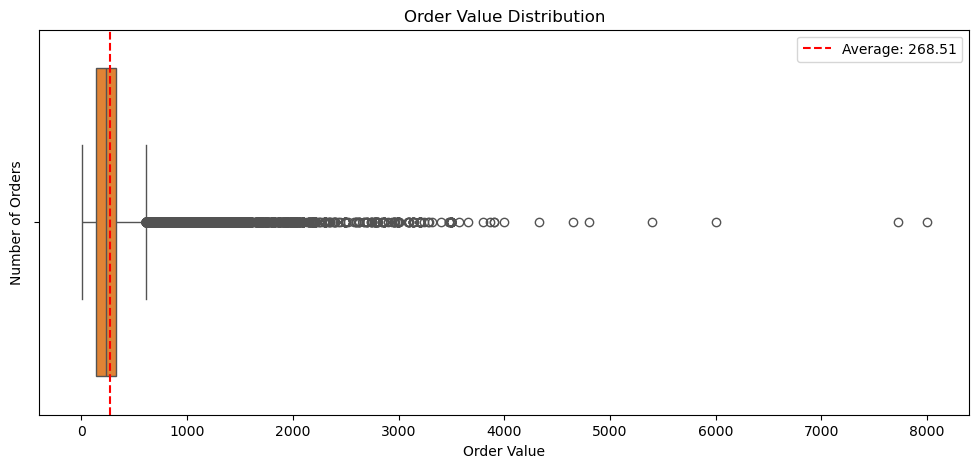

In [102]:
# Order Value Distribution   

avg_order_value = orders['price'].mean()
max_order_value = orders['price'].max()

print(f"Average order value: {avg_order_value:.2f}")
print(f"Maximum order value: {max_order_value:.2f}")

plt.figure(figsize=(12, 5))

sns.boxplot(
    data= orders,
    x='price',
    color="#fc8019"
)

plt.axvline(avg_order_value, color="red", linestyle="--", label=f"Average: {avg_order_value:.2f}")

plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()

In [103]:
# Outlier data

Q1 = orders['price'].quantile(0.25)
Q3 = orders['price'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
outlier = orders[orders['price']> upper_limit]

print(f"upper outlier limit : {upper_limit:.2f}")
print(f"No of high value outlier : {outlier.shape[0]}")
print(f"Percentage of outlier: {(outlier.shape[0]/orders.shape[0])*100:.2f}")

upper outlier limit : 614.00
No of high value outlier : 9876
Percentage of outlier: 5.00


In [104]:
outlier_counts=orders[orders['price'] > 614.00].value_counts().sum()
overall_orders = orders['order_id'].value_counts().sum()

pct_outlier_orders = outlier_counts*100/overall_orders
print(pct_outlier_orders)

5.0022792888618755


In [105]:
overall_orders = orders['order_id'].value_counts().sum()
overall_orders

np.int64(197430)

### Order Value Distribution — Summary: 

The average order value sits at ₹268.Order Value Distribution — Summary: The average order value sits at ₹268.51 against a maximum of ₹8,000, confirming that the vast majority of Swiggy orders are low-to-mid ticket. 

The IQR-based outlier threshold is ₹614, beyond which 9,876 orders (exactly 5% of total 197,430) are flagged as high-value. These outliers likely represent bulk orders, corporate catering, or premium restaurant purchases rather than typical consumer behaviour.

The boxplot makes this skew visually obvious — the entire core distribution is compressed below ₹500 while a long right tail stretches to ₹8,000. 

Business takeaway: 95% of revenue is built on sub-₹614 orders, so pricing strategy, discounts, and delivery fees should be optimised for this majority band — while the 5% high-value segment deserves a separate retention and loyalty focus.

## Top 10 restaurants by total sales

In [108]:
restaurant_sales = orders.merge(restaurants,on = 'restaurant_id',how = 'left')

In [109]:
restaurant_sales_data = restaurant_sales.groupby('restaurant_name').agg(
    total_revenue=('price', 'sum'),
    avg_order=('price', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

In [110]:
top_10_restaurant_sales =restaurant_sales_data.sort_values(by='total_revenue' ,ascending = False).head(10).reset_index()

In [111]:
top_10_restaurant_sales

,index,restaurant_name,total_revenue,avg_order,order_count
0,428,KFC,4246951.70,327.671607,12961
1,524,McDonald's,3343094.58,247.087552,13530
2,643,Pizza Hut,2133265.69,326.736972,6529
3,138,Burger King,1900817.09,267.118759,7116
4,251,Domino's Pizza,1834022.32,333.944341,5492
5,603,Olio - The Wood Fired Pizzeria,1236369.00,381.477630,3241
6,494,LunchBox - Meals and Thalis,1101141.00,234.285319,4700
7,84,Baskin Robbins - Ice Cream Desserts,860591.94,205.049307,4197
8,279,"Faasos - Wraps, Rolls & Shawarma",780215.00,239.623771,3256
9,891,The Good Bowl,673343.00,252.661538,2665


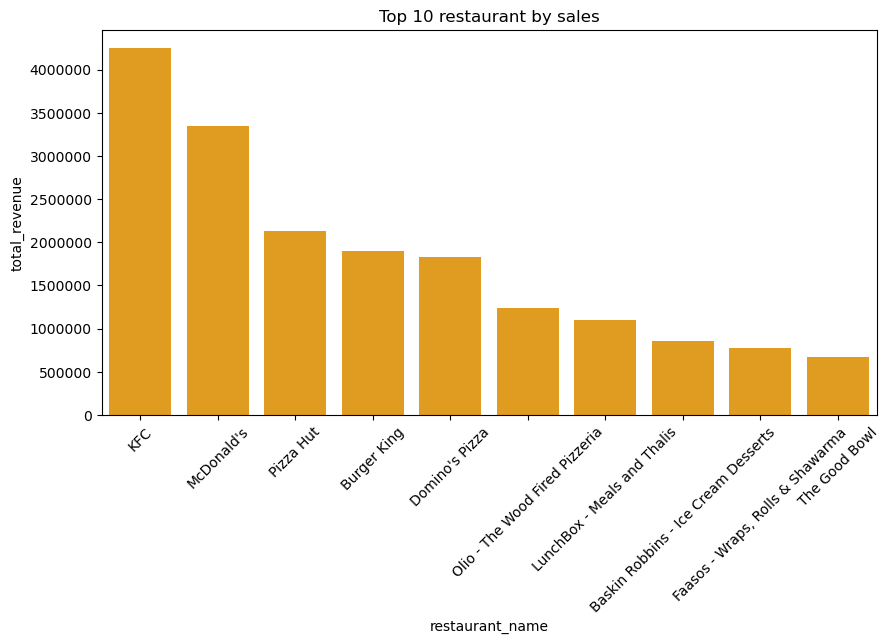

In [112]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_10_restaurant_sales, x='restaurant_name', y='total_revenue',color = 'orange')
plt.title('Top 10 restaurant by sales')
plt.ticklabel_format(style='Plain', axis='y')
plt.xticks(rotation=45)
plt.show()

### Top 10 Restaurants — Summary: 

KFC leads in total revenue (₹42.5L) despite McDonald's having the highest order count (13,530 vs KFC's 12,961), meaning KFC customers spend more per order (₹327 vs ₹247). Domino's Pizza has the highest AOV among QSR chains at ₹334, while Olio - The Wood Fired Pizzeria tops all restaurants at ₹381 AOV with just 3,241 orders — a classic low-volume, high-value premium segment. Pizza Hut sits comfortably at #3 in revenue (₹21.3L) with a balanced mix of volume and spend. The bottom half (Baskin Robbins, Faasos, The Good Bowl) trail significantly in both revenue and orders. Key insight: McDonald's wins on popularity but KFC wins on revenue — optimising McDonald's AOV through upselling combos could easily flip the revenue ranking.

# --------------------------------------------------------------------------------------------
# Top 10 dishes by sales 
# --------------------------------------------------------------------------------------------

In [115]:
dish_sales_data = orders.merge(dish, left_on ='food_id',right_on = 'dish_id',how = 'left')

In [116]:
Total_sale_by_dish = dish_sales_data.groupby('dish_name').agg(
    Total_Revenue = ('price','sum'),
    avg_orders = ('price','mean'),
    total_orders = ('order_id','count')).reset_index()
print(Total_sale_by_dish)

                                              dish_name  Total_Revenue  \
0                                  1 1 Dabba at 209 Veg          418.0   
1                              1 1 Dabba at 259 Non Veg          478.0   
2      1 1 Lazeez Bhuna Murgh Biryani Kebab Thali Combo         4428.0   
3        1 1 Zaikedaar Paneer Biryani Kebab Thali Combo        17712.0   
4                               1 Ajwain Butter Paratha           35.0   
...                                                 ...            ...   
55208                           shree ram special thali          449.0   
55209                       special Chicken leg Biryani          280.0   
55210                                     veg Ela Choru           90.0   
55211                                     veg chow mein          178.0   
55212                                        vej pakoda          149.0   

       avg_orders  total_orders  
0           209.0             2  
1           239.0             2  
2        

In [117]:
Top_10_dish = Total_sale_by_dish.sort_values(by = 'Total_Revenue' ,ascending = False).head(10).reset_index()
print(Top_10_dish)

   index                          dish_name  Total_Revenue   avg_orders  \
0   5514      Bold BBQ Veggie Thin n Crispy       99617.00   749.000000   
1  28558      Korean Thai Roll Chicken Meal       95591.57   568.997440   
2  21971  Full House Popcorn Chicken Bucket       79200.00  1200.000000   
3  51162               Triple Chicken Feast       70757.00   409.000000   
4  37825               Paneer Butter Masala       70713.82   294.640917   
5  25612  Indian Tandoori Roll Chicken Meal       70392.05   419.000298   
6   4850              Big 12 Chicken Bucket       69738.12   820.448471   
7  54461                     Veggie Supreme       67841.00   379.000000   
8  24875           Hot Crispy Chicken 8 pcs       67359.90   801.903571   
9  51422    Ultimate Savings Chicken Bucket       64611.68   769.186667   

   total_orders  
0           133  
1           168  
2            66  
3           173  
4           240  
5           168  
6            85  
7           179  
8           

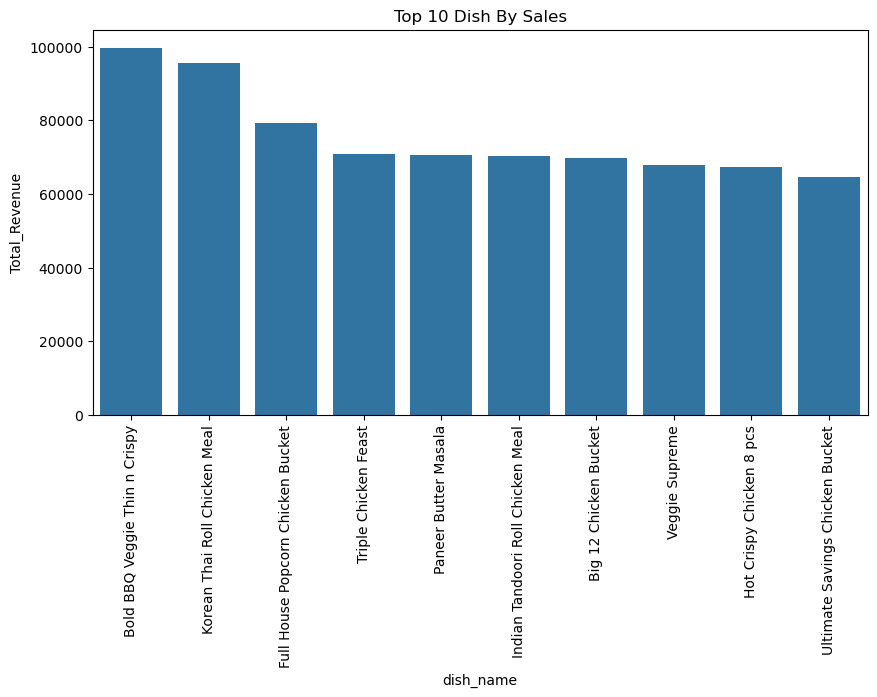

In [118]:
plt.figure(figsize= (10,5))

sns.barplot(data = Top_10_dish,x= 'dish_name',y = 'Total_Revenue')
plt.title('Top 10 Dish By Sales')
plt.ticklabel_format(style = 'plain',axis = 'y')
plt.xticks(rotation = 90)
plt.show()

### Finding: Top 10 Dishes by Revenue

The top 10 dishes by revenue show that high-revenue dishes don't always mean high order volume. 

Some dishes command a higher price per order, driving revenue with fewer transactions. This distinction matters for menu optimization — Swiggy can promote high-AOV dishes to increase revenue without necessarily increasing order volume.

# Top Categories by Revenue

In [196]:
Category_revenue = dish_sales_data.groupby('category').agg(
    Total_Revenue = ('price','sum'),
    Avg_order_value = ('price','mean'),
    Total_orders = ('order_id','count')
).sort_values(by = 'Total_Revenue', ascending = False).reset_index().head(10)

In [198]:
Category_revenue

,category,Total_Revenue,Avg_order_value,Total_orders
0,Recommended,7188936.53,298.296122,24100
1,Main Course,760045.00,256.858736,2959
2,Burger Combos 3 Pc Meals,507773.55,381.497784,1331
3,McSaver Combos 2 Pc Meals,431696.65,229.016790,1885
4,Desserts,416311.28,141.410082,2944
5,Korean Spicy FestLimited Time Only,405191.00,343.382203,1180
6,Starters,398756.00,238.347878,1673
7,Freshly Scooped Tubs,394286.00,414.165966,952
8,Sweets,387800.40,226.122682,1715
9,Exclusive Deals Save upto 40,383369.28,223.278556,1717


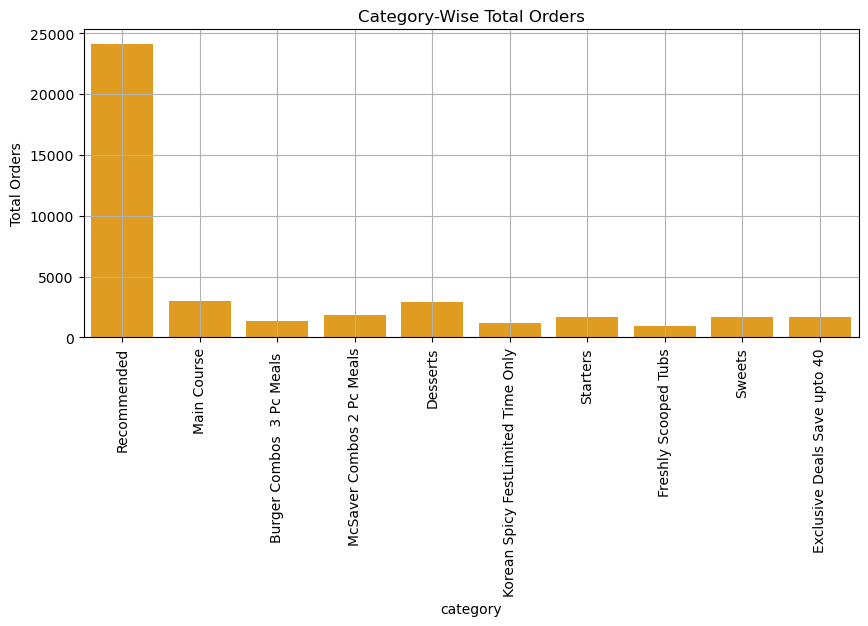

In [230]:
plt.figure(figsize=(10,4))

# Total orders
sns.barplot(data=Category_revenue, x='category', y='Total_orders', 
              color='orange')
plt.title('Category-Wise Total Orders')
plt.xlabel('category')
plt.ylabel('Total Orders')
plt.xticks(rotation = 90)
plt.grid(True)


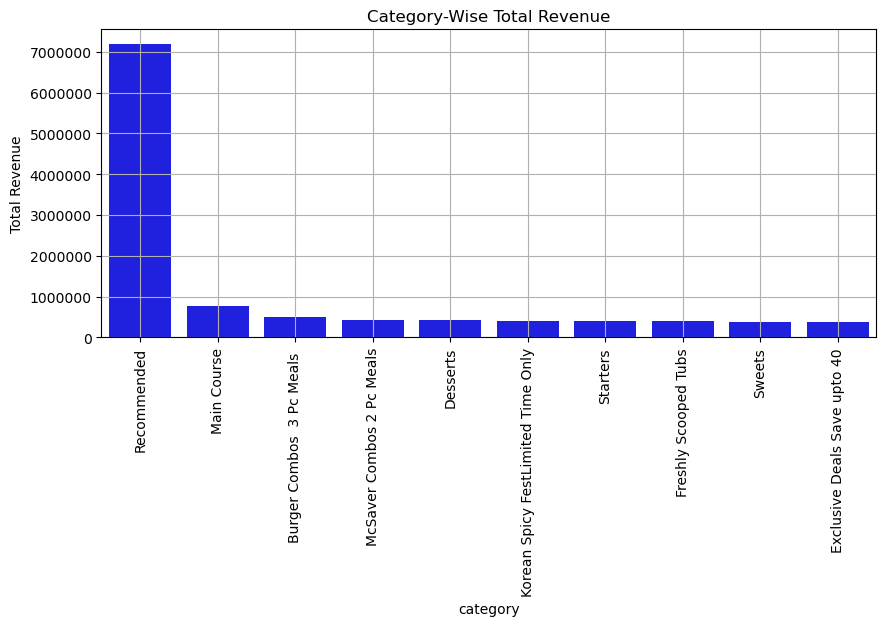

In [234]:
plt.figure(figsize=(10,4))

# Total Revenue
sns.barplot(data=Category_revenue, x='category', y='Total_Revenue', 
              color='blue')
plt.title('Category-Wise Total Revenue')
plt.xlabel('category')
plt.ylabel('Total Revenue')
plt.ticklabel_format(style = 'plain',axis = 'y')
plt.xticks(rotation = 90)
plt.grid(True)

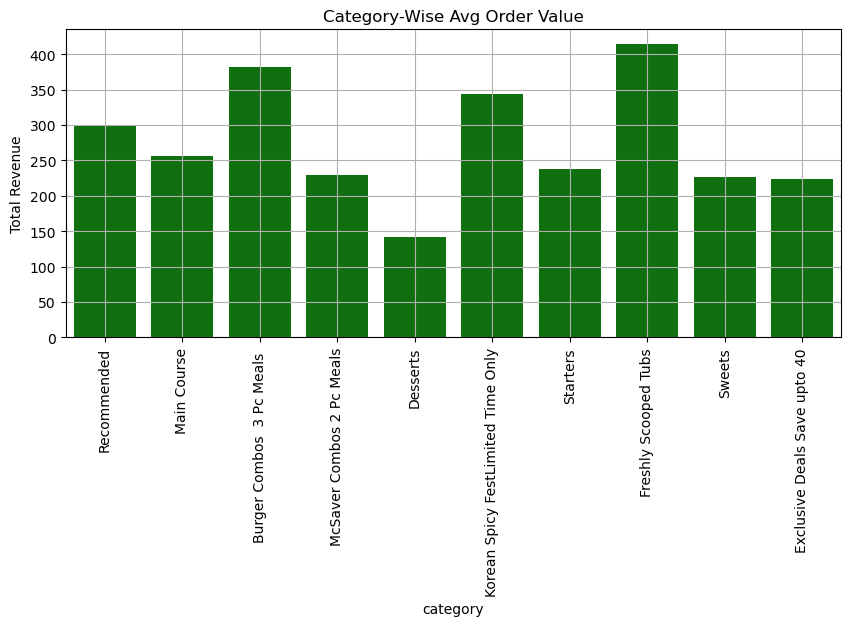

In [244]:
plt.figure(figsize=(10,4))

# Average order value
sns.barplot(data=Category_revenue, x='category', y='Avg_order_value', 
              color='green')
plt.title('Category-Wise Avg Order Value')
plt.xlabel('category')
plt.ylabel('Total Revenue')
plt.ticklabel_format(style = 'plain',axis = 'y')
plt.xticks(rotation = 90)
plt.grid(True)

### Category Revenue Summary:

Recommended is the top-performing category by a wide margin — ₹71.9L in revenue across 24,100 orders — driven by repeat customers reordering their favorites through Swiggy's recommendation engine, making it the strongest signal of customer loyalty and retention.

Main Course (₹7.6L) and Burger Combos (₹5.1L) serve as the primary discovery categories, capturing new and exploratory customers with healthy order volumes.

High-AOV categories like Freshly Scooped Tubs (₹414), Burger Combos (₹381), and Korean Spicy Fest (₹343) attract fewer but higher-spending customers, representing an upsell opportunity worth promoting.

Desserts stand out as a volume driver with 2,944 orders but the lowest avg order value (₹141), suggesting it works best as an add-on rather than a standalone order.

Bottom line: Retention is strong — the Recommended engine is doing its job. The growth lever lies in converting exploratory Main Course and Combo buyers into repeat customers while nudging high-AOV items to a wider audience.

# -------------------------------------------------------------------------------------------
# Orders trend over time 
# -------------------------------------------------------------------------------------------

# Merge Orders Data with Date Dimension for Time-Based Analysis
Objective:

Merge the orders table with the date dimension table to perform time-based analysis such as:

### Monthly order trends
### Weekend vs Weekday analysis

In [122]:
orders_data = orders.merge(date,on ='date_id', how = 'left')
print(orders_data)

        order_id  date_id  location_id  restaurant_id  food_id  price  rating  \
0              1        1            1              1        1  133.9     4.0   
1              2        2            2              2        2   52.0     4.5   
2              3        3            2              2        3  117.0     4.7   
3              4        4            2              2        4   65.0     4.6   
4              5        5            2              2        5  130.0     4.0   
...          ...      ...          ...            ...      ...    ...     ...   
197425    197426      190          989            993    82887  112.0     4.4   
197426    197427      156          989            993    82888  140.0     4.4   
197427    197428       57          989            993    82889  126.0     4.4   
197428    197429      231          989            993    82890   85.0     4.4   
197429    197430      242          989            993    82891  100.0     4.4   

        rating_count order_

In [123]:
monthly_sales_data = orders_data.groupby(['year','month','month_name']).agg(Total_Revenue = ('price','sum'),
                                                          avg_order_value = ('price','mean'),
                                                          total_orders = ('order_id','count')).reset_index()
print(monthly_sales_data)

   year  month month_name  Total_Revenue  avg_order_value  total_orders
0  2025      1        Jan     6825186.03       268.729271         25398
1  2025      2        Feb     6269105.67       269.106528         23296
2  2025      3        Mar     6573530.07       269.384889         24402
3  2025      4        Apr     6594515.00       268.200545         24588
4  2025      5        May     6793558.40       269.692672         25190
5  2025      6        Jun     6514183.19       267.138946         24385
6  2025      7        Jul     6650965.51       266.678649         24940
7  2025      8        Aug     6791461.90       269.171333         25231


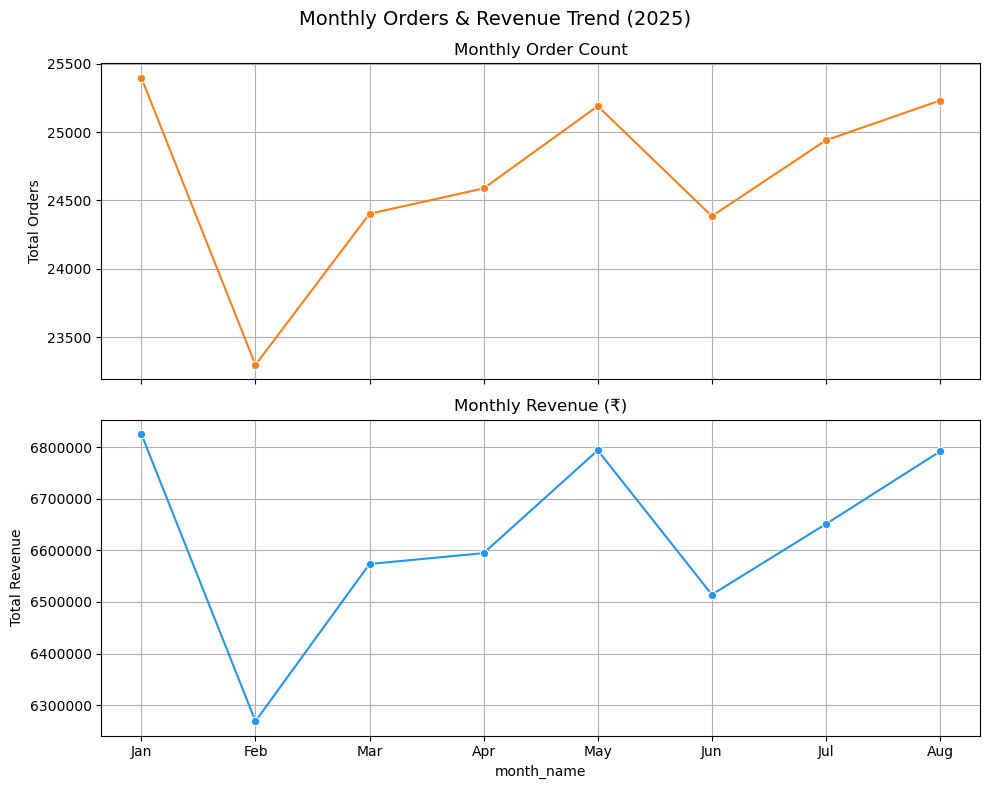

In [124]:

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Orders trend
sns.lineplot(data=monthly_sales_data, x='month_name', y='total_orders', 
             ax=axes[0], color='#fc8019', marker='o')
axes[0].set_title('Monthly Order Count')
axes[0].set_ylabel('Total Orders')
axes[0].grid(True)

# Revenue trend
sns.lineplot(data=monthly_sales_data, x='month_name', y='Total_Revenue', 
             ax=axes[1], color='#2196F3', marker='o')
axes[1].set_title('Monthly Revenue (₹)')
axes[1].set_ylabel('Total Revenue')
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].grid(True)

plt.suptitle('Monthly Orders & Revenue Trend (2025)', fontsize=14)
plt.tight_layout()
plt.show()

Monthly Orders & Revenue Trend (2025): 
January started strong (25K orders, ₹68L revenue) before sharply dropping in February to the lowest point of the year (23K orders, ₹63L) — likely a post-holiday slowdown. Recovery began in March and held steady through April, with May hitting a clear peak (26k orders, ₹68L), possibly driven by summer demand or promotions. June dipped again (24K orders, ₹65L), but July–August show a consistent upward recovery trend closing near January highs. The business pattern is W-shaped — two dips (Feb, Jun) sandwiching two peaks (Jan, May) — suggesting bi-monthly demand cycles worth planning inventory and offers around.

# Weekend vs Weekday Analysis

In [127]:
weekend_data = orders_data.groupby('is_weekend').agg(
    Total_Revenue =('price','sum'),
    Average_order_value = ('price','mean'),
    Total_orders = ('order_id','count')    
)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18316\4177892507.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekend_data, x = 'is_weekend',y='Total_Revenue',ax=axes[0], palette=['#fc8019','#d3d3d3'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18316\4177892507.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekend_data, x = 'is_weekend',y='Total_orders',ax=axes[1], palette=['#fc8019','#d3d3d3'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18316\4177892507.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weeken

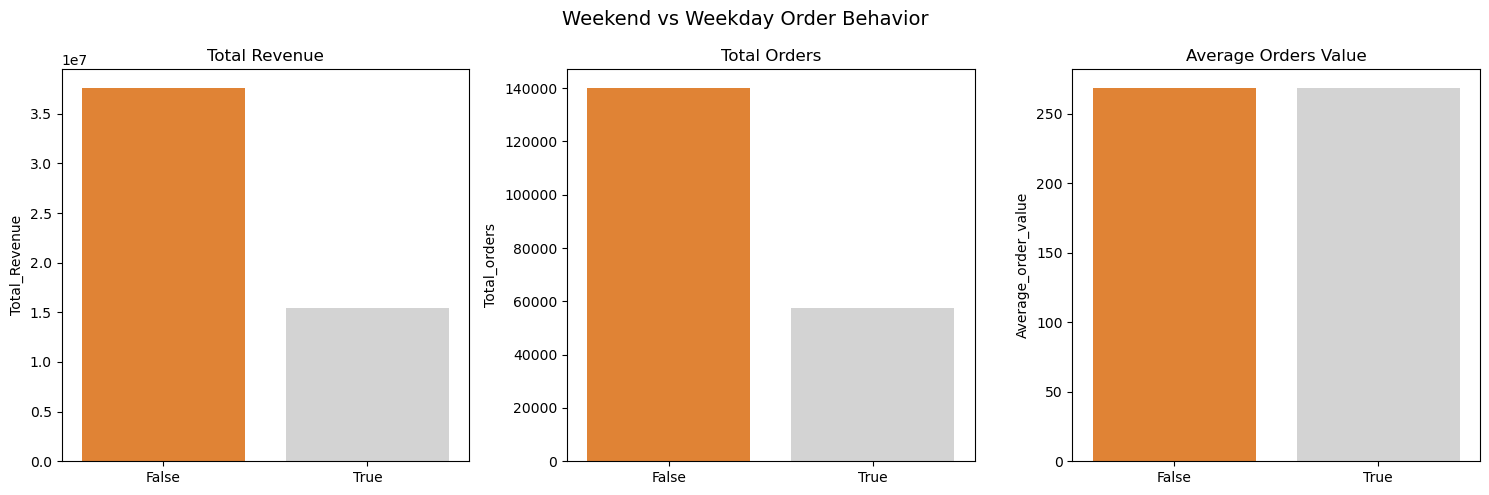

            Total_Revenue  Average_order_value  Total_orders
is_weekend                                                  
False         37591566.35           268.476670        140018
True          15420939.42           268.601328         57412


In [128]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(data=weekend_data, x = 'is_weekend',y='Total_Revenue',ax=axes[0], palette=['#fc8019','#d3d3d3'])
axes[0].set_title('Total Revenue')
axes[0].set_xlabel('')

sns.barplot(data=weekend_data, x = 'is_weekend',y='Total_orders',ax=axes[1], palette=['#fc8019','#d3d3d3'])
axes[1].set_title('Total Orders')
axes[1].set_xlabel('')

sns.barplot(data=weekend_data, x = 'is_weekend',y='Average_order_value',ax=axes[2], palette=['#fc8019','#d3d3d3'])
axes[2].set_title('Average Orders Value')
axes[2].set_xlabel('')

plt.suptitle('Weekend vs Weekday Order Behavior', fontsize=14)
plt.tight_layout()
plt.show()

print(weekend_data)

In [251]:
weekday_orders = 140018
weekend_orders = 57412
Total = weekday_orders + weekend_orders
pct_weekday = weekday_orders*100/Total

print(f"Percentage of weekday's orders are :{round(pct_weekday,0)}")

Percentage of weekday's orders are :71.0


### Weekend vs Weekday:

Weekdays drive 71% of orders (140K vs 57K) and ₹3.76 Cr in revenue vs ₹1.54 Cr on weekends. Despite the volume gap, average order value is nearly identical at ~₹268, meaning customers spend the same regardless of the day. 

The weekday dominance likely reflects office lunch/dinner ordering as Swiggy's core use case. Lower weekend orders suggest customers prefer dining out or cooking at home on off-days. A targeted weekend promotion on delivery fees — not discounts — could close this gap without hurting margins.

# ---------------------------------------------------------------
# Location / City Level Analysis
# ---------------------------------------------------------------


In [132]:
location_orders = orders.merge(locations, on='location_id', how='left')

city_sales = location_orders.groupby('city').agg(
    total_revenue=('price', 'sum'),
    total_orders=('order_id', 'count'),
    avg_order_value=('price', 'mean')
).reset_index().sort_values('total_revenue', ascending=False)

top_10_cities = city_sales.head(10)

print(top_10_cities)

          city  total_revenue  total_orders  avg_order_value
3    Bengaluru     5456798.41         20077       271.793515
18     Lucknow     3117359.65         10192       305.863388
11   Hyderabad     3021711.62         10309       293.113941
19      Mumbai     3015573.35         10507       287.006124
20   New Delhi     2829180.60         10191       277.615602
1    Ahmedabad     2817836.02         10185       276.665294
5   Chandigarh     2809440.69         10065       279.129726
17     Kolkata     2662801.76         10046       265.060896
6      Chennai     2642594.63         10042       263.154215
14      Jaipur     2502932.61         10286       243.333911


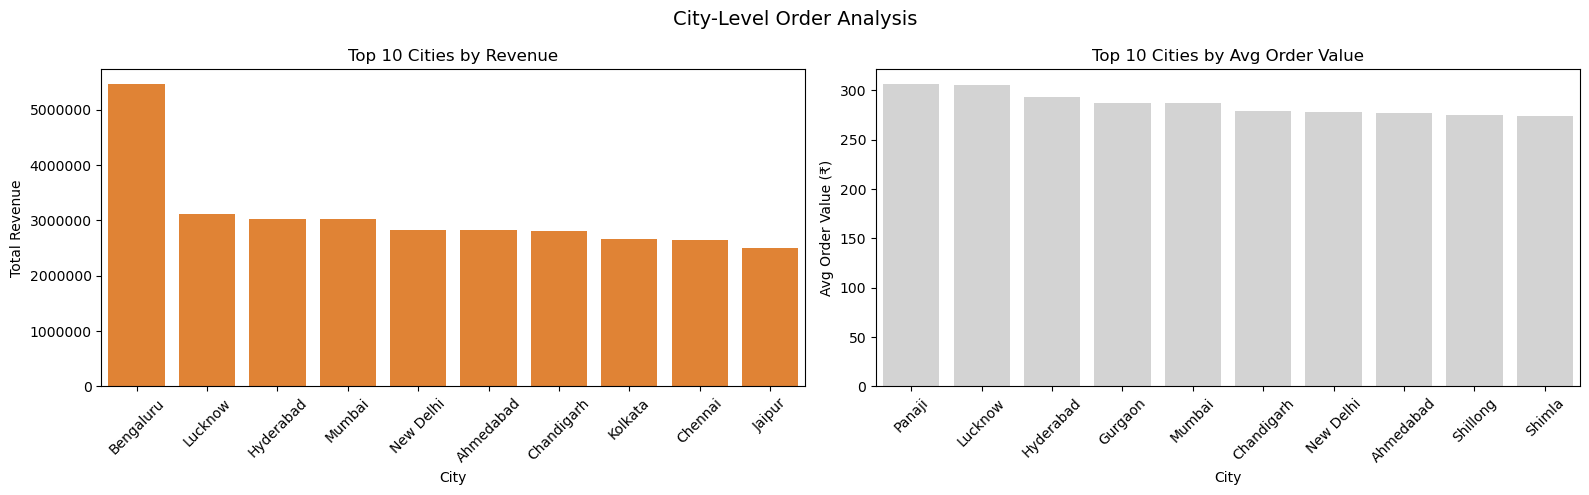

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1 - Revenue by City
sns.barplot(data=top_10_cities, x='city', y='total_revenue', ax=axes[0], color='#fc8019')
axes[0].set_title('Top 10 Cities by Revenue')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Total Revenue')
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2 - Avg Order Value by City
city_aov = city_sales.sort_values('avg_order_value', ascending=False).head(10)
sns.barplot(data=city_aov, x='city', y='avg_order_value', ax=axes[1], color='#d3d3d3')
axes[1].set_title('Top 10 Cities by Avg Order Value')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Avg Order Value (₹)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('City-Level Order Analysis', fontsize=14)
plt.tight_layout()
plt.show()

###  City-Level Order Analysis:

Bengaluru dominates total revenue at ₹53L — nearly 2x the next city (Lucknow at ₹30L) — driven purely by order volume, not higher spending. 

The remaining 9 cities (Lucknow to Jaipur) are tightly clustered between ₹24L–₹30L, suggesting fairly even market penetration outside Bengaluru.

On average order value, the spread is remarkably flat across all cities (~₹275–₹305), meaning no city shows premium or budget ordering behavior. 

Panaji and Lucknow lead AOV slightly at ~₹305, hinting at a smaller but higher-quality customer base. The key takeaway: Bengaluru's lead in revenue 

# Price vs Rating — Is there a correlation?



A common assumption is that customers who spend more tend to rate higher. 
To test this, we compare order value distribution across each rating band.

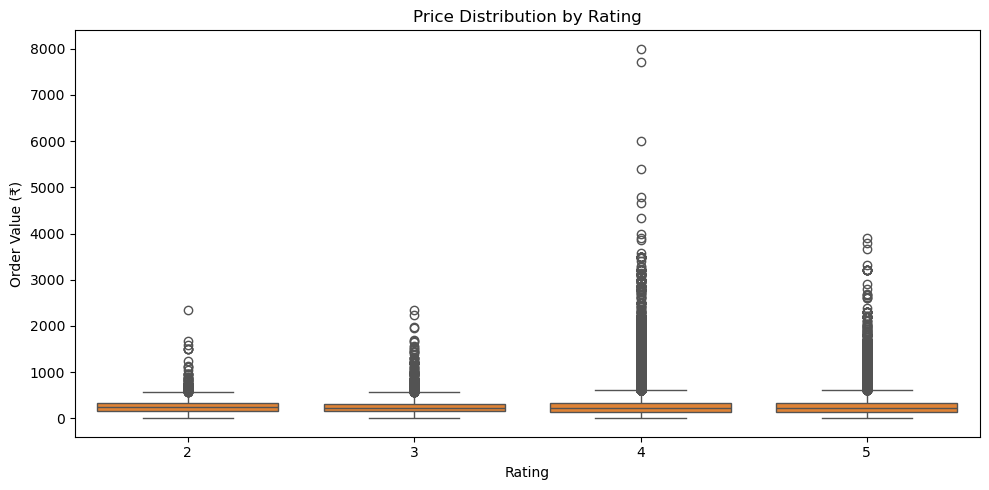

In [137]:
orders['rating_band'] = orders['rating'].round(0).astype(int)  
# isntead of 1.5,2.5 we groups rating  into 2, 3, 4, 5

plt.figure(figsize=(10, 5))
sns.boxplot(data=orders, x='rating_band', y='price', color='#fc8019')
plt.title('Price Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Order Value (₹)')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

### Finding: Price vs Rating

Correlation between price and rating: 0.03 — essentially no relationship.
Median order value is consistent across all rating bands (2 through 5),
hovering around ₹250–300.

Rating 4 and 5 do show more high-value outliers — however this is likely 
because higher-rated restaurants attract significantly more orders overall, 
so the outlier count is proportional to order volume, not to rating itself.

The core finding holds: price does not drive rating. Food quality and 
delivery experience remain the primary factors customers rate on.

# Key Takeaways — Swiggy Sales Analysis

## Dataset
- 197,430 orders | Jan–Aug 2025 | 5 tables (star schema)

## Order Value
- Average order value: ₹268.51 | Max: ₹8,000
- 5% of orders are outliers above ₹614 — likely bulk/group orders

## Restaurants
- KFC leads in total revenue among all 993 restaurants
- High revenue ≠ high AOV — some restaurants drive volume, others drive value

## Dishes
- Top dishes by revenue show a premium pricing pattern with fewer but higher-value orders

## Categories
- **Recommended** dominates (₹71.9L, 24K orders) — repeat customers, strongest retention signal
- **Main Course & Combos** — volume drivers, likely new/exploratory customers
- **Tubs & Korean Fest** — high AOV, underleveraged upsell opportunity
- **Desserts** — high volume, lowest AOV (₹141) — works best as an add-on

## Time Trends
- January peak followed by a February dip — needs root cause investigation
- Weekend/Weekday orders show equal AOV — opportunity for targeted promotions on weekends

## Geography
- Bengaluru leads in volume | Panaji leads in AOV

---